In [1]:
from platosim.simfile import SimFile
from platosim.simulation import Simulation
from platosim.validation import switchOffAllEffects
import os
import math
import numpy as np
import matplotlib.pyplot as plt

In [3]:
sim = Simulation("CTI")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-column exposure

sim["ObservingParameters/NumExposures"] = 1
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 1

# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

# Enable CTI

sim["CCD/IncludeCTIeffects"] = "yes"
# sim["SubField/SubPixels"] = 1

sim["PSF/Model"] = "MappedFromFileSymmetrical"

# Simple Implementation

In [4]:
sim["CCD/CTI/Model"] = "Simple"

In [5]:
output = sim.run(removeOutputFile = True)
column = output.getImage(0)


2020-06-04 14:50:36 WARNING Simulation: no information about detected stars to write to HDF5
2020-06-04 14:50:36 WARNING Camera: No star positions to write to HDF5 file.



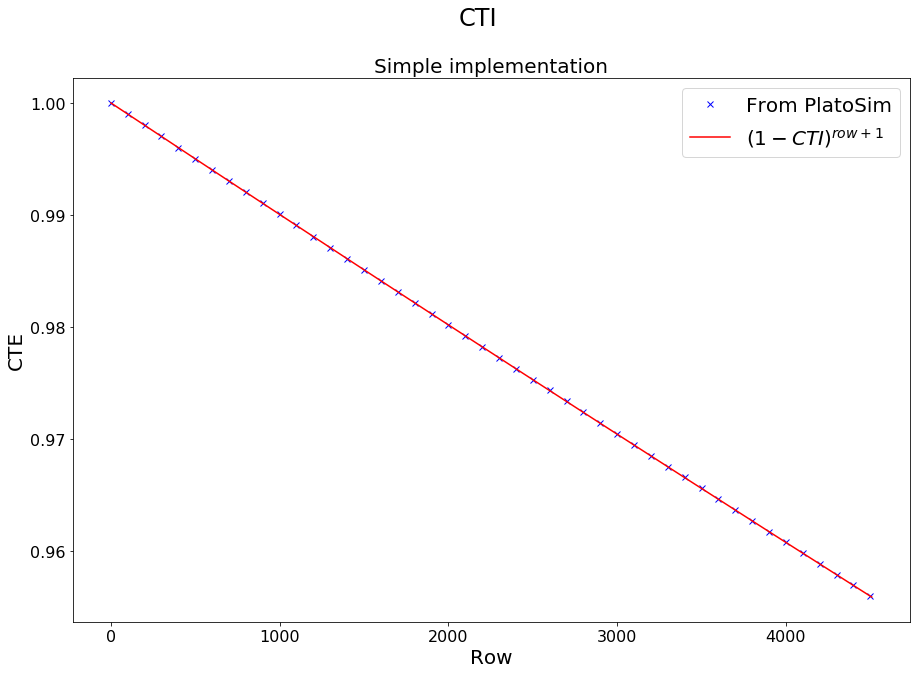

In [6]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

cte = sim["CCD/CTI/Simple/MeanCTE"]
sel = np.arange(0, 4600, 100)
rows = np.arange(4510)
plt.plot(rows[sel], column[sel] / column[0] * cte, "bx", label="From PlatoSim")



#####################
# Expected efficiency
#####################

expectedEfficiency = np.array([])

for row in rows:
    
    expectedEfficiency = np.append(expectedEfficiency, math.pow(cte, row + 1))

plt.plot(rows, expectedEfficiency, "r", label="$(1 - CTI)^{row + 1}$")



########
# Layout
########

plt.suptitle("CTI", fontsize = 24)
plt.title("Simple implementation", fontsize=20)
plt.xlabel("Row", fontsize = 20)
plt.ylabel("CTE", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

In [7]:
starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

sim["Sky/SkyBackground"] = 0

In [8]:
positionRows = np.arange(0, 5000, 500)
columns = []

for row in positionRows:
    print(row)
    
    sim.createStarCatalogFileFromPixelCoordinates(np.array([row + 0.5]), np.array([0.5]), np.array([12.5]), np.array([1]), starCatalogFilename)
    output = sim.run(removeOutputFile = True)
    column = output.getImage(0)
    print(np.min(column), np.max(column))
    
    columns.append(column)

0


0.0 102841.97
500


0.0 102329.04
1000


0.0 101818.67
1500


0.0 101310.84
2000


0.0 100805.555
2500


0.0 100302.78
3000


0.0 99802.516
3500


0.0 99304.75
4000


0.0 98809.46
4500


0.0 98316.64


(90000, 104000)

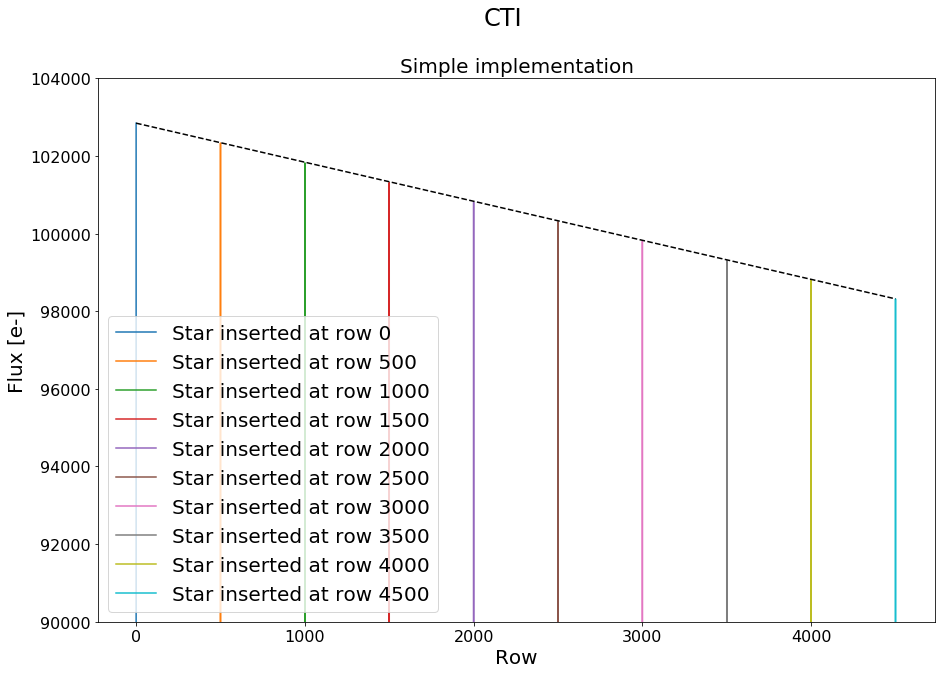

In [9]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############


for index in np.arange(len(positionRows)):
    
    plt.plot(columns[index], label="Star inserted at row " + str(positionRows[index]))

maximum = np.max(columns[0])
minimum = np.max(columns[-1])

plt.plot([0,4500], [maximum, minimum], "k--")

    
    
########
# Layout
########

plt.suptitle("CTI", fontsize = 24)
plt.title("Simple implementation", fontsize=20)
plt.xlabel("Row", fontsize = 20)
plt.ylabel("Flux [e-]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
# plt.xlim([1000, 1005])
plt.ylim([90000, 104000])

# Short et al. 2013

In [10]:
sim["CCD/CTI/Model"] = "Short2013"

In [11]:
starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

In [12]:
# positionRows = np.arange(0, 5000, 500)
columns = []

for row in positionRows:
    print(row)
    
    sim.createStarCatalogFileFromPixelCoordinates(np.array([row + 0.5]), np.array([0.5]), np.array([12.5]), np.array([1]), starCatalogFilename)
    output = sim.run(removeOutputFile = True)
    column = output.getImage(0)
    print(np.min(column), np.max(column))
    
    columns.append(column)

0


0.0 102843.0
500


0.0 102843.0
1000


0.0 102843.0
1500


0.0 102843.0
2000


0.0 102843.0
2500


0.0 102843.0
3000


0.0 102843.0
3500


0.0 102843.0
4000


0.0 102843.0
4500


0.0 102843.0


(70000, 104000)

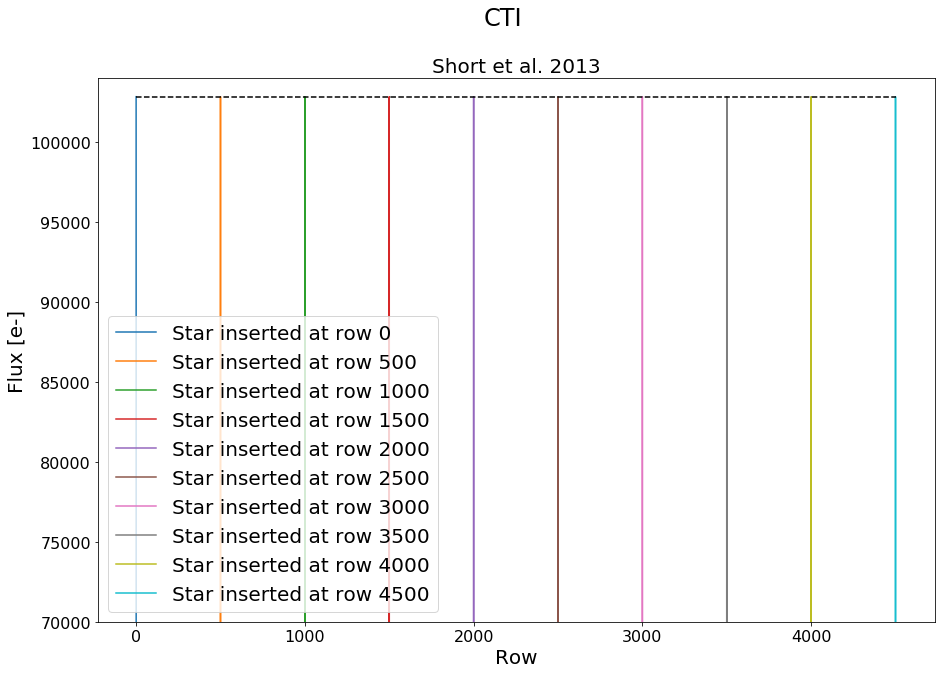

In [13]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############


for index in np.arange(len(positionRows)):
    
    plt.plot(columns[index], label="Star inserted at row " + str(positionRows[index]))

maximum = np.max(columns[0])
minimum = np.max(columns[-1])

plt.plot([0,4500], [maximum, minimum], "k--")

    
    
########
# Layout
########

plt.suptitle("CTI", fontsize = 24)
plt.title("Short et al. 2013", fontsize=20)
plt.xlabel("Row", fontsize = 20)
plt.ylabel("Flux [e-]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

plt.ylim([70000, 104000])

In [14]:
exposureIndex = int(sim["ObservingParameters/MissionDuration"] * 365.25 * 24 * 60 * 60 / sim["ObservingParameters/CycleTime"])

sim["ObservingParameters/BeginExposureNr"] = exposureIndex

In [15]:
positionRows = np.arange(0, 5000, 500)
columns = []

for row in positionRows:
    print(row)
    
    sim.createStarCatalogFileFromPixelCoordinates(np.array([row + 0.5]), np.array([0.5]), np.array([12.5]), np.array([1]), starCatalogFilename)
    output = sim.run(removeOutputFile = True)
    column = output.getImage(exposureIndex)
    print(np.min(column), np.max(column))
    
    columns.append(column)

0


4.4020275e-05 100431.77
500


0.0 96474.984
1000


0.0 92807.3
1500


0.0 89401.35
2000


0.0 86232.695
2500


0.0 83279.5
3000


0.0 80522.28
3500


0.0 77943.586
4000


0.0 75527.81
4500


0.0 73260.98


(70000, 104000)

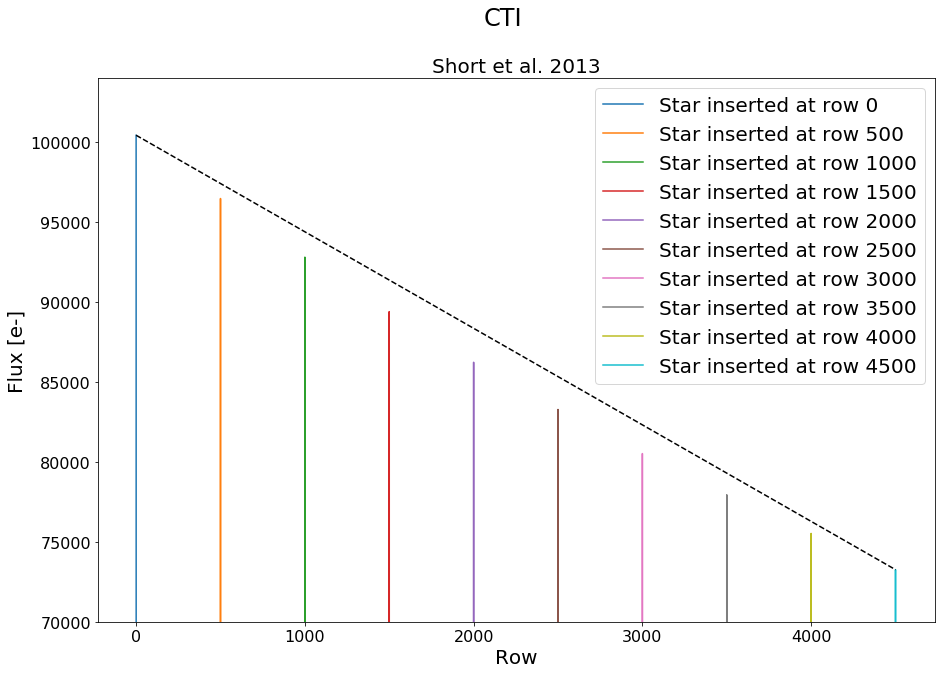

In [16]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############


for index in np.arange(len(positionRows)):
    
    plt.plot(columns[index], label="Star inserted at row " + str(positionRows[index]))

maximum = np.max(columns[0])
minimum = np.max(columns[-1])

plt.plot([0,4500], [maximum, minimum], "k--")

    
    
########
# Layout
########

plt.suptitle("CTI", fontsize = 24)
plt.title("Short et al. 2013", fontsize=20)
plt.xlabel("Row", fontsize = 20)
plt.ylabel("Flux [e-]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

plt.ylim([70000, 104000])

0




















1




















2




















3




















4




















5




















6




















7






















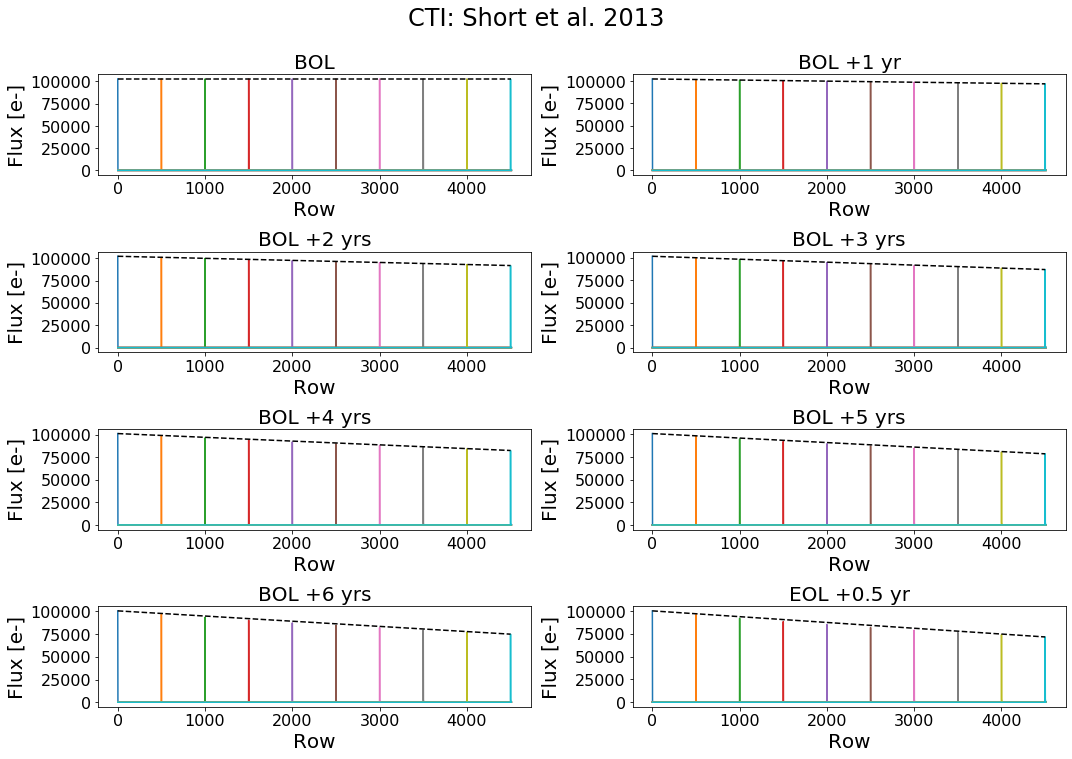

In [34]:
fig = plt.figure(figsize = (15, 10))

for yearsIntoMission in range(0, 8):
    
    print(yearsIntoMission)
    
    ax = fig.add_subplot(4, 2, yearsIntoMission + 1)
    
    exposureIndex = int(yearsIntoMission * 365.25 * 24 * 60 * 60 / sim["ObservingParameters/CycleTime"])
    sim["ObservingParameters/BeginExposureNr"] = exposureIndex
    
    columns = []

    for row in positionRows:
    
        sim.createStarCatalogFileFromPixelCoordinates(np.array([row + 0.5]), np.array([0.5]), np.array([12.5]), np.array([1]), starCatalogFilename)
        output = sim.run(removeOutputFile = True)
        column = output.getImage(exposureIndex)
        columns.append(column)
        
    for index in np.arange(len(positionRows)):
    
        plt.plot(columns[index], label="Star inserted at row " + str(positionRows[index]))
        
    
        
    maximum = np.max(columns[0])
    minimum = np.max(columns[-1])

    plt.plot([0,4500], [maximum, minimum], "k--")
    
    plt.title("Years into mission: " + str(yearsIntoMission), fontsize=20)
    if yearsIntoMission == 0:
        plt.title("BOL", fontsize=20)
    elif yearsIntoMission == 1:
        plt.title("BOL +" + str(yearsIntoMission) + " yr", fontsize=20)
    elif yearsIntoMission > sim["ObservingParameters/MissionDuration"]:
        plt.title("EOL +" + str(yearsIntoMission - sim["ObservingParameters/MissionDuration"]) + " yr", fontsize=20)
    else:
        plt.title("BOL +" + str(yearsIntoMission) + " yrs", fontsize=20)
    plt.xlabel("Row", fontsize=20)
    plt.ylabel("Flux [e-]", fontsize=20)
    
    for tick in ax.xaxis.get_major_ticks():
        tick.label.set_fontsize(16)
    
    for tick in ax.yaxis.get_major_ticks():
        tick.label.set_fontsize(16)
        

plt.suptitle("CTI: Short et al. 2013", y=1.05, fontsize=24)
plt.tight_layout()